In [ ]:
!pip install pyspark


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EarthquakeBigDataAnalysis") \
    .getOrCreate()


In [ ]:
df = spark.read.csv("EarthquakeBigDataAnalysis.csv", header=True, inferSchema=True)

In [ ]:
#Basic Exploration

df.printSchema()
df.count()
df.show(5)


root
 |-- time: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- depth: double (nullable = true)
 |-- mag: double (nullable = true)
 |-- place: string (nullable = true)
 |-- type: string (nullable = true)

+--------------------+--------+---------+-------+---+--------------------+----------+
|                time|latitude|longitude|  depth|mag|               place|      type|
+--------------------+--------+---------+-------+---+--------------------+----------+
|2025-03-03 15:40:...| 12.6846| 146.2399|   10.0|5.1|174 km ESE of Yig...|earthquake|
|2025-03-03 10:25:...|-16.7565| -177.364|413.683|5.4|282 km SSE of Alo...|earthquake|
|2025-03-03 06:25:...| 27.3373|  61.0748| 32.943|5.2|41 km ENE of Iran...|earthquake|
|2025-03-02 18:42:...| -3.5151| 129.4579| 28.891|5.2|59 km ESE of Maso...|earthquake|
|2025-03-02 14:16:...|-10.2343|   66.062|   10.0|5.3|    Mid-Indian Ridge|earthquake|
+--------------------+--------+---------+

In [ ]:
from pyspark.sql.functions import col, count, when

df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+----+--------+---------+-----+---+-----+----+
|time|latitude|longitude|depth|mag|place|type|
+----+--------+---------+-----+---+-----+----+
|   0|       0|        0|    0|  0|    0|   0|
+----+--------+---------+-----+---+-----+----+



In [ ]:
#Remove rows with null magnitude:
df = df.filter(df.mag.isNotNull())

In [ ]:
df.show()

+--------------------+--------+---------+-------+---+--------------------+----------+
|                time|latitude|longitude|  depth|mag|               place|      type|
+--------------------+--------+---------+-------+---+--------------------+----------+
|2025-03-03 15:40:...| 12.6846| 146.2399|   10.0|5.1|174 km ESE of Yig...|earthquake|
|2025-03-03 10:25:...|-16.7565| -177.364|413.683|5.4|282 km SSE of Alo...|earthquake|
|2025-03-03 06:25:...| 27.3373|  61.0748| 32.943|5.2|41 km ENE of Iran...|earthquake|
|2025-03-02 18:42:...| -3.5151| 129.4579| 28.891|5.2|59 km ESE of Maso...|earthquake|
|2025-03-02 14:16:...|-10.2343|   66.062|   10.0|5.3|    Mid-Indian Ridge|earthquake|
|2025-03-02 08:14:...| 14.1721|  39.9337|   10.0|5.2|52 km ESE of Ādīg...|earthquake|
|2025-03-01 23:42:...|-29.3998|-177.3562| 51.427|5.2|Kermadec Islands,...|earthquake|
|2025-03-01 20:02:...| 13.4753| 145.5991| 65.557|5.3|77 km E of Yigo V...|earthquake|
|2025-03-01 13:59:...|   7.867| 126.7422| 17.616|5.0|2

In [ ]:
#Top 10 Places with Most Earthquakes

df.groupBy("place").count().orderBy("count", ascending=False).show(10)

+--------------------+-----+
|               place|count|
+--------------------+-----+
|South Sandwich Is...|  860|
|Kermadec Islands ...|  450|
|southeast of the ...|  264|
|Kermadec Islands,...|  241|
|south of the Fiji...|  195|
|southern Mid-Atla...|  193|
|Pacific-Antarctic...|  184|
|south of the Kerm...|  177|
|Izu Islands, Japa...|  153|
|northern Mid-Atla...|  139|
+--------------------+-----+
only showing top 10 rows


In [ ]:
#Average Magnitude by Year

from pyspark.sql.functions import year

df = df.withColumn("year", year(df.time))
df.groupBy("year").avg("mag").orderBy("year").show()

+----+-----------------+
|year|         avg(mag)|
+----+-----------------+
|2015|5.376730911786517|
|2016|5.349536928487718|
|2017|5.318295019157107|
|2018|5.337912895927619|
|2019|5.330632218845003|
|2020|5.341400000000017|
|2021|5.317714414009916|
|2022|5.324104347826108|
|2023|5.355202247191024|
|2024|5.297485069674863|
|2025|             5.25|
+----+-----------------+



In [ ]:
#Deepest Earthquake

df.orderBy("depth", ascending=False).show(5)


+--------------------+--------+---------+------+---+--------------------+----------+----+
|                time|latitude|longitude| depth|mag|               place|      type|year|
+--------------------+--------+---------+------+---+--------------------+----------+----+
|2018-09-06 15:49:...|-18.4743| 179.3502|670.81|7.9|45 km S of Levuka...|earthquake|2018|
|2018-01-16 19:57:...|-19.4497|-179.2959|666.76|5.9|211 km SE of Levu...|earthquake|2018|
|2015-05-30 11:23:...| 27.8386| 140.4931| 664.0|7.8|Bonin Islands, Ja...|earthquake|2015|
|2018-09-06 16:08:...|-17.9933|-179.6692|660.43|5.1|107 km E of Levuk...|earthquake|2018|
|2022-11-09 09:51:...|-26.0901| 178.3427| 660.0|7.0|south of the Fiji...|earthquake|2022|
+--------------------+--------+---------+------+---+--------------------+----------+----+
only showing top 5 rows


In [ ]:
#Highest Magnitude Recorded

df.orderBy("mag", ascending=False).show(5)

+--------------------+--------+---------+-----+---+--------------------+----------+----+
|                time|latitude|longitude|depth|mag|               place|      type|year|
+--------------------+--------+---------+-----+---+--------------------+----------+----+
|2015-09-16 22:54:...|-31.5729| -71.6744|22.44|8.3|48 km W of Illape...|earthquake|2015|
|2021-07-29 06:15:...| 55.3635|-157.8876| 35.0|8.2|2021 Chignik, Ala...|earthquake|2021|
|2018-08-19 00:19:...|-18.1125| -178.153|600.0|8.2|2018 Fiji Earthquake|earthquake|2018|
|2017-09-08 04:49:...| 15.0222| -93.8993|47.39|8.2|2017 Tehuantepec,...|earthquake|2017|
|2021-08-12 18:35:...|-58.3753| -25.2637|22.79|8.1|2021 South Sandwi...|earthquake|2021|
+--------------------+--------+---------+-----+---+--------------------+----------+----+
only showing top 5 rows


In [ ]:
top_places = df.groupBy("place").count().orderBy("count", ascending=False).limit(10).toPandas()

**Ghraph** **PLoting**

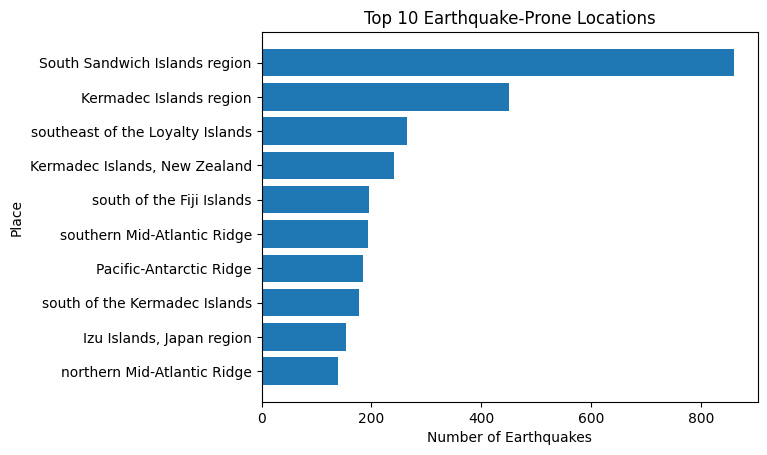

In [ ]:
#Top 10 Earthquake-Prone Places

top_places = df.groupBy("place") \
               .count() \
               .orderBy("count", ascending=False) \
               .limit(10) \
               .toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_places['place'], top_places['count'])
plt.xlabel("Number of Earthquakes")
plt.ylabel("Place")
plt.title("Top 10 Earthquake-Prone Locations")
plt.gca().invert_yaxis()
plt.show()

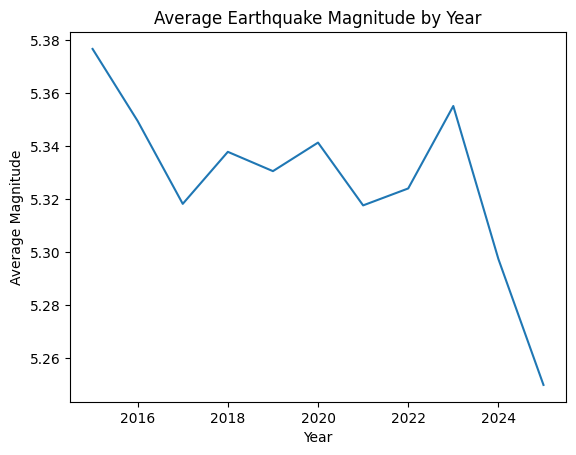

In [ ]:
#Average Magnitude by Year

avg_mag_year = df.groupBy("year") \
                 .avg("mag") \
                 .orderBy("year") \
                 .toPandas()

plt.figure()
plt.plot(avg_mag_year['year'], avg_mag_year['avg(mag)'])
plt.xlabel("Year")
plt.ylabel("Average Magnitude")
plt.title("Average Earthquake Magnitude by Year")
plt.show()

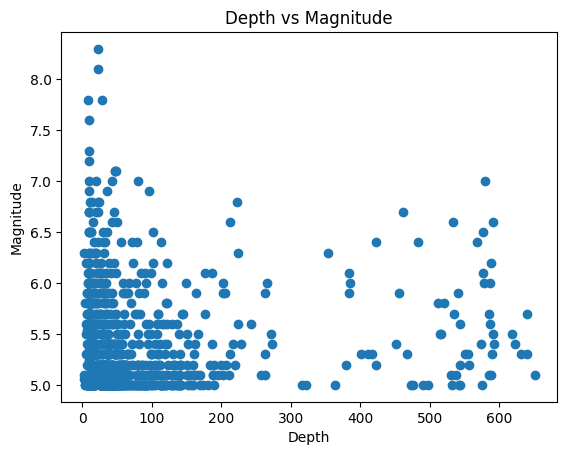

In [ ]:
#Depth vs Magnitude Scatter

sample_df = df.select("depth", "mag").sample(0.1).toPandas()

plt.figure()
plt.scatter(sample_df['depth'], sample_df['mag'])
plt.xlabel("Depth")
plt.ylabel("Magnitude")
plt.title("Depth vs Magnitude")
plt.show()

**📌 Key Insights**

Certain regions experience significantly higher earthquake frequency.

Average magnitude has remained relatively stable over the years.

Deeper earthquakes do not always mean stronger magnitude.

High-magnitude earthquakes are rare but geographically concentrated.

**This project demonstrates scalable big data processing using PySpark on global earthquake data. The analysis reveals patterns in earthquake frequency, magnitude distribution, and geographic concentration. Spark’s distributed computation capabilities allowed efficient processing of large-scale geospatial data.**